# Feature Engineering - Synthetic Psychotherapy Dropout Data

This notebook engineers clinically motivated features on synthetic psychotherapy data: PHQ-9 change trajectory, increasing session gaps, and longest attendance streak.

## Imports and setup

Load project modules and set plotting style.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

for _path in (os.getcwd(), os.path.abspath(os.path.join(os.getcwd(), ".."))):
    if os.path.isdir(os.path.join(_path, "src")) and _path not in sys.path:
        sys.path.insert(0, _path)

from src.data_loader import generate_synthetic_data
from src.feature_engineering import (
    compute_attendance_streak,
    compute_phq9_change_rate,
    compute_session_gap_pattern,
    run_all_features,
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

if os.path.basename(os.path.normpath(os.getcwd())).lower() == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
else:
    PROJECT_ROOT = os.getcwd()

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: C:\Users\HP\Desktop\therapy-dropout-prediction


## Load synthetic cohort

Generate synthetic patients (500) with clinically plausible dropout prevalence.

In [2]:
df = generate_synthetic_data(n_patients=500, seed=42)

# Build a simple session attendance indicator for streak feature computation
df["attended"] = (df["attendance_consistency"] >= 0.5).astype(int)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())


Shape: (500, 10)
Dropout rate: 72.60%
Correlation phq9 vs dropout: 0.342
Correlation attendance vs dropout: -0.217
Correlation gap vs dropout: 0.219
Shape: (500, 11)
Columns: ['patient_id', 'phq9_score', 'session_number', 'session_frequency_per_month', 'attendance_consistency', 'gap_between_sessions_days', 'mood_rating', 'age', 'phq9_change_rate', 'dropout', 'attended']


,patient_id,phq9_score,session_number,session_frequency_per_month,attendance_consistency,gap_between_sessions_days,mood_rating,age,phq9_change_rate,dropout,attended
0,1,6,5,6.716196,0.473210,37,4,63,-0.650639,0,0
1,2,19,9,4.073944,0.968193,9,8,61,0.899925,0,1
2,3,14,12,3.638611,0.185526,29,7,38,0.155252,1,0
3,4,10,1,4.238758,0.868623,30,5,61,-1.757484,1,1
4,5,7,1,3.109645,0.776597,24,8,28,0.759999,1,1


## PHQ-9 change rate

Compute per-patient symptom trajectory (negative means improvement).

   patient_id  session_number  phq9_score  phq9_change_rate
0           1               5           6               0.0
1           2               9          19               0.0
2           3              12          14               0.0
3           4               1          10               0.0
4           5               1           7               0.0


C:\Users\HP\Desktop\therapy-dropout-prediction\src\feature_engineering.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_patient_change_rate)


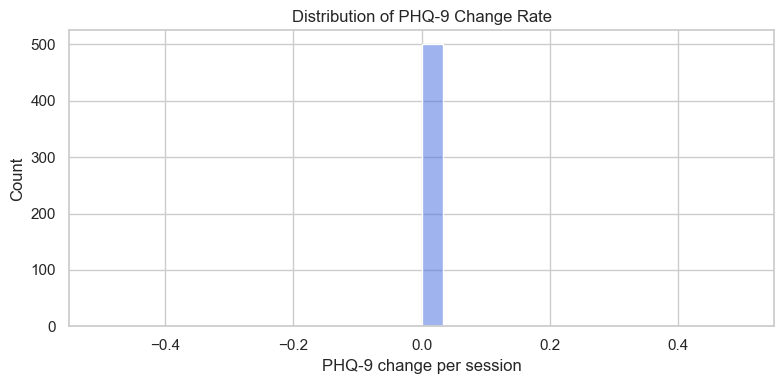

In [3]:
df_phq = compute_phq9_change_rate(df)
print(df_phq[["patient_id", "session_number", "phq9_score", "phq9_change_rate"]].head())

plt.figure(figsize=(8, 4))
sns.histplot(df_phq["phq9_change_rate"], bins=30, kde=True, color="royalblue")
plt.title("Distribution of PHQ-9 Change Rate")
plt.xlabel("PHQ-9 change per session")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Increasing session gap pattern

Flag patients with progressively widening gaps between sessions.

   patient_id  gap_between_sessions_days  gap_increasing
0           1                         37               0
1           2                          9               0
2           3                         29               0
3           4                         30               0
4           5                         24               0


C:\Users\HP\Desktop\therapy-dropout-prediction\src\feature_engineering.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_flag_increasing_gaps)


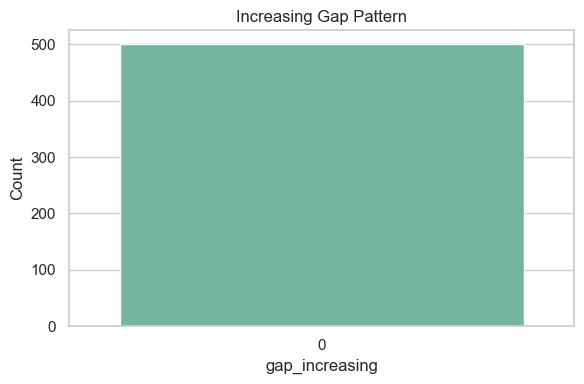

In [4]:
df_gap = compute_session_gap_pattern(df_phq)
print(df_gap[["patient_id", "gap_between_sessions_days", "gap_increasing"]].head())

vc = df_gap["gap_increasing"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=vc.index.astype(str), y=vc.values, hue=vc.index.astype(str), palette="Set2", legend=False)
plt.title("Increasing Gap Pattern")
plt.xlabel("gap_increasing")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Attendance streak

Compute longest run of attended sessions as an engagement-protective factor.

   patient_id  attended  max_attendance_streak
0           1         0                      0
1           2         1                      1
2           3         0                      0
3           4         1                      1
4           5         1                      1


C:\Users\HP\Desktop\therapy-dropout-prediction\src\feature_engineering.py:176: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_longest_streak)


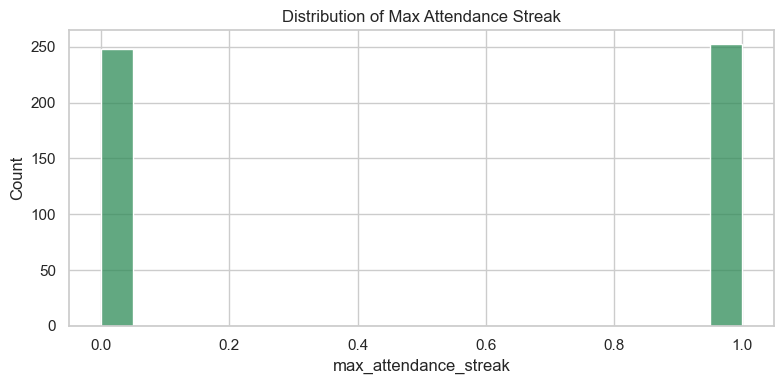

In [5]:
df_streak = compute_attendance_streak(df_gap)
print(df_streak[["patient_id", "attended", "max_attendance_streak"]].head())

plt.figure(figsize=(8, 4))
sns.histplot(df_streak["max_attendance_streak"], bins=20, kde=False, color="seagreen")
plt.title("Distribution of Max Attendance Streak")
plt.xlabel("max_attendance_streak")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Run full feature pipeline

Apply all engineering steps in one call and verify added columns.

In [6]:
df_final = run_all_features(df)
print("Final shape:", df_final.shape)
print("Added columns present:", [c for c in ["phq9_change_rate", "gap_increasing", "max_attendance_streak"] if c in df_final.columns])


C:\Users\HP\Desktop\therapy-dropout-prediction\src\feature_engineering.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_patient_change_rate)
C:\Users\HP\Desktop\therapy-dropout-prediction\src\feature_engineering.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_flag_increasing_gaps)


Final shape: (500, 13)
Added columns present: ['phq9_change_rate', 'gap_increasing', 'max_attendance_streak']


C:\Users\HP\Desktop\therapy-dropout-prediction\src\feature_engineering.py:176: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_longest_streak)


## Save processed synthetic dataset

Persist engineered features for modeling notebook.

In [7]:
out_path = os.path.join(PROCESSED_DIR, "synthetic_featured.csv")
df_final.to_csv(out_path, index=False)
print("Saved:", out_path)


Saved: C:\Users\HP\Desktop\therapy-dropout-prediction\data\processed\synthetic_featured.csv
